# Day 25 - Hypothesis Testing in Python

Objective:
Learn how to perform and interpret statistical hypothesis tests using Python and SciPy.

Concepts Covered:
- Shapiro-Wilk Test
- P-Value Interpretation
- One-Sample T-Test
- Pearson Correlation Test
- Statistical Decision Making

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
movie=pd.read_csv('/content/IMDb Movies India.csv',encoding="latin1")

In [ ]:
movie.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


Part-1:
NORMALITY TESTING

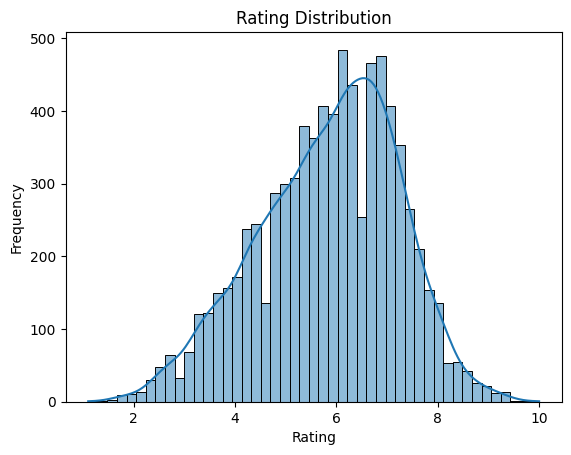

In [ ]:
sns.histplot(movie["Rating"],kde=True)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Ratings appear approximately bell-shaped.
Most movies are concentrated between ratings 5 and 7.


In [ ]:
movie["Rating"].describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


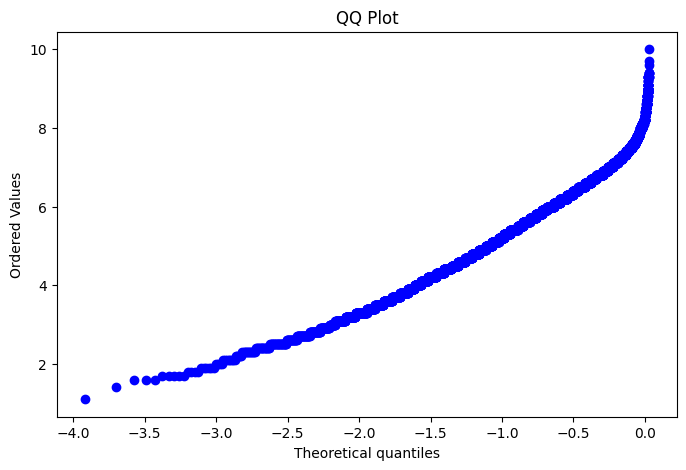

In [5]:
from scipy.stats import probplot

plt.figure(figsize=(8,5))

probplot(
    movie["Rating"],
    plot=plt
)

plt.title("QQ Plot")
plt.show()

QQ Plot helps compare sample distribution
against a theoretical normal distribution.

H₀: Ratings are normally distributed.

H₁: Ratings are not normally distributed.

In [12]:
from scipy.stats import shapiro

stat,p=shapiro(movie["Rating"].dropna())

print("stat=",stat)
print("p-value=",p)

stat= 0.9880030712746994
p-value= 2.3305914143679107e-25


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7919.
  res = hypotest_fun_out(*samples, **kwds)


In [13]:
alpha=0.05

if p<alpha:
    print("Reject H₀")
else:
    print("Fail to Reject H₀")

Reject H₀


### Shapiro-Wilk Test

H₀: Ratings are normally distributed.

H₁: Ratings are not normally distributed.

Result:
- Statistic = 0.9880
- P-value = 2.33e-25

Decision:
Since the p-value is less than 0.05, the null hypothesis was rejected.

Conclusion:
The Rating variable does not perfectly follow a normal distribution.

Note:
The dataset contains 7919 observations. For large datasets, the Shapiro-Wilk test is highly sensitive and may detect even minor deviations from normality.

Claim:
Average movie rating = 6

H₀ : μ = 6

H₁ : μ ≠ 6

In [14]:
from scipy.stats import ttest_1samp

stat,p=ttest_1samp(movie["Rating"].dropna(),popmean=6)

print("stat=",stat)
print("p-value=",p)

stat= -10.19984604907265
p-value= 2.8048021383823228e-24


In [16]:
alpha=0.05

if p<alpha:
    print("Reject H₀")
else:
    print("Fail to Reject H₀")

Reject H₀


Since the p-value was less than 0.05, the null hypothesis was rejected.

This suggests that the average movie rating differs significantly from the hypothesized mean of 6.

In [43]:
movie["Votes"] = (
    movie["Votes"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

movie["Votes"] = pd.to_numeric(
    movie["Votes"],
    errors="coerce"
)

from scipy.stats import pearsonr

stat,p=pearsonr(movie["Rating"].dropna(),movie["Votes"].dropna())

print("stat=",stat)
print("p-value=",p)

stat= 0.12663518946687147
p-value= 1.132833874874008e-29


The Pearson Correlation Test was performed to examine the relationship between movie ratings and vote counts.

Results:
- Correlation Coefficient (r) = 0.1266
- P-value = 1.13e-29

Since the p-value is less than 0.05, the null hypothesis was rejected.

This indicates that a statistically significant relationship exists between Votes and Rating.

However, the correlation coefficient is very low, suggesting that the relationship is weak. Therefore, vote count alone is not a strong predictor of movie ratings.

In [38]:
import plotly.express as px

fig = px.scatter(
    movie,
    x="Votes",
    y="Rating",
    hover_data=["Name"],
    title="Rating vs Votes"
)

fig.update_layout(
    xaxis_title="Votes",
    yaxis_title="Rating"
)

fig.show()

# Conclusion

In this notebook, I applied hypothesis testing concepts using Python.

Key concepts covered:
- Shapiro-Wilk Normality Test
- One-Sample T-Test
- Pearson Correlation Test
- P-Value Interpretation

Key findings:
- Movie ratings did not perfectly follow a normal distribution.
- Statistical testing was used to evaluate claims about average ratings.
- A statistically significant but weak positive relationship was found between votes and ratings.

This notebook helped bridge the gap between statistical theory and practical implementation.

# Key Findings

1. Movie ratings are not perfectly normally distributed.
2. Shapiro-Wilk test rejected the normality assumption.
3. One-Sample T-Test demonstrated how to test a population mean claim.
4. Pearson Correlation showed a weak positive relationship between votes and ratings.
5. Statistical significance does not always imply a strong relationship.